In [225]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib.ticker import FuncFormatter
import scipy.stats as stats

In [226]:
df = pd.read_csv("synthetic_online_retail_data.csv")
df.head()

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.0,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,NaN,M,59
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.0,F,64
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.0,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.0,F,33


In [227]:
df.tail()

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
995,67967,2024-05-04,965,40,Books & Stationery,Notebook,3,495.24,Cash on Delivery,Hodgemouth,NaN,NaN,30
996,99828,2024-09-12,510,40,Books & Stationery,Story Book,5,427.73,Credit Card,Douglastown,3.0,F,72
997,92290,2024-11-06,445,10,Electronics,Smartphone,5,354.64,Bank Transfer,New Amberville,NaN,M,49
998,61427,2024-09-17,410,10,Electronics,Laptop,4,221.54,Cash on Delivery,New Sean,3.0,M,71
999,20658,2024-11-06,177,40,Books & Stationery,Pen,3,196.97,Cash on Delivery,North Kelsey,1.0,M,34


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1000 non-null   int64  
 1   order_date      1000 non-null   object 
 2   product_id      1000 non-null   int64  
 3   category_id     1000 non-null   int64  
 4   category_name   1000 non-null   object 
 5   product_name    1000 non-null   object 
 6   quantity        1000 non-null   int64  
 7   price           1000 non-null   float64
 8   payment_method  1000 non-null   object 
 9   city            1000 non-null   object 
 10  review_score    799 non-null    float64
 11  gender          897 non-null    object 
 12  age             1000 non-null   int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB


In [229]:
df.describe()

,customer_id,product_id,category_id,quantity,price,review_score,age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,799.000000,1000.000000
mean,55490.723000,540.726000,30.030000,2.947000,251.850660,3.992491,46.382000
std,25910.185857,261.737704,14.370303,1.413573,139.194688,1.239469,16.569992
min,10201.000000,100.000000,10.000000,1.000000,10.720000,1.000000,18.000000
25%,33857.000000,311.750000,20.000000,2.000000,128.525000,3.000000,32.000000
50%,54619.500000,542.500000,30.000000,3.000000,250.220000,4.000000,47.000000
75%,77848.500000,770.750000,40.000000,4.000000,366.467500,5.000000,61.000000
max,99923.000000,995.000000,50.000000,5.000000,499.500000,5.000000,75.000000


In [230]:
df.shape

(1000, 13)

In [231]:
df.size

13000

In [232]:
df["category_name"].value_counts()

category_name
Sports & Outdoors     211
Electronics           207
Fashion               198
Books & Stationery    193
Home & Living         191
Name: count, dtype: int64

In [233]:
df["gender"].value_counts()

gender
M    457
F    440
Name: count, dtype: int64

In [234]:
df.isnull().sum()

customer_id         0
order_date          0
product_id          0
category_id         0
category_name       0
product_name        0
quantity            0
price               0
payment_method      0
city                0
review_score      201
gender            103
age                 0
dtype: int64

In [235]:
df = df.apply(lambda col: col.fillna(col.mean()) if col.dtype != 'O' else col)
df = df.apply(lambda col: col.fillna(col.mode()[0]) if not col.mode().empty else col)



In [236]:
df.isnull().sum()

customer_id       0
order_date        0
product_id        0
category_id       0
category_name     0
product_name      0
quantity          0
price             0
payment_method    0
city              0
review_score      0
gender            0
age               0
dtype: int64

In [237]:
# Ensure order_date is in datetime format
df['order_date'] = pd.to_datetime(df['order_date'])


In [238]:
# Create a new column for total price per order line
df['total_price'] = df['quantity'] * df['price']


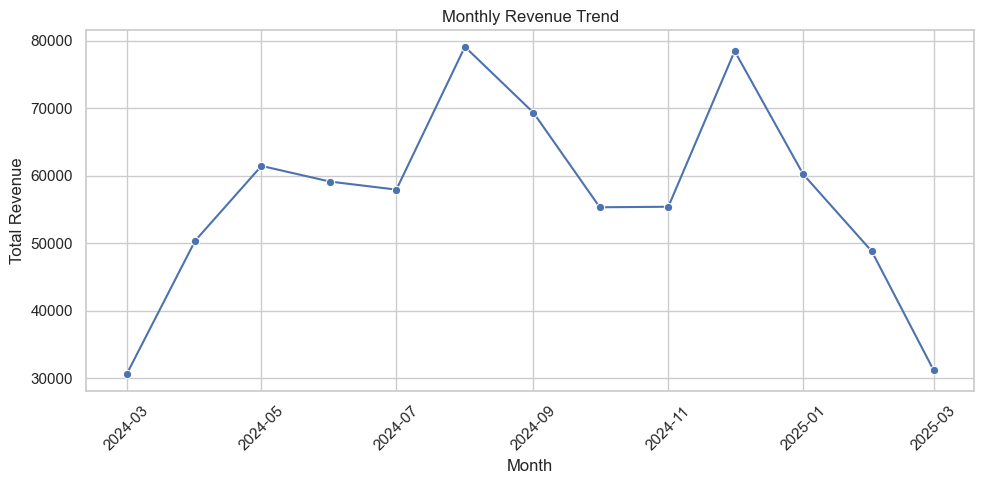

In [239]:
# Set a consistent style
sns.set(style="whitegrid")

# --- 1. Monthly Sales Trend (Total Revenue) ---
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['total_price'].sum().reset_index()
monthly_sales['order_date'] = monthly_sales['order_date'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='order_date', y='total_price', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


We can observe:

High sales spikes in certain months, possibly due to promotions or seasonal demand.

Some dips suggest months with lower customer activity.

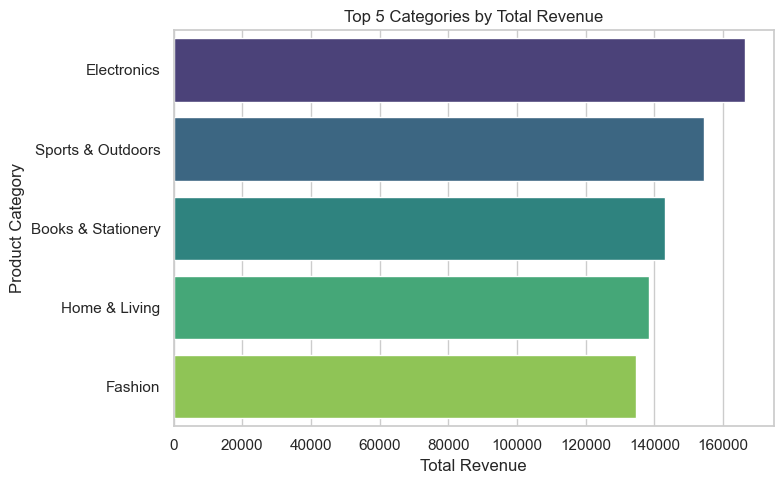

In [241]:
# --- 2. Top 5 Categories by Total Revenue ---
category_revenue = df.groupby('category_name')['total_price'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette="viridis")
plt.title("Top 5 Categories by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


1. Top 5 Categories by Total Revenue
Electronics and Fashion dominate total sales.

Books & Stationery contributes the least among the top 5.

Indicates where customers spend the most.

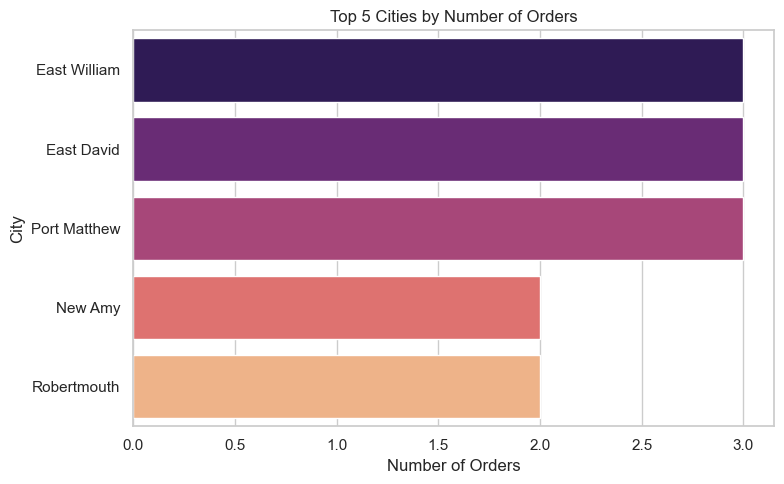

In [243]:
# --- 3. Top 5 Cities by Number of Orders ---
city_orders = df['city'].value_counts().head(5)

plt.figure(figsize=(8, 5))
sns.barplot(x=city_orders.values, y=city_orders.index, palette="magma")
plt.title("Top 5 Cities by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("City")
plt.tight_layout()
plt.show()

2. Top 5 Cities by Number of Orders
These cities are your highest demand zones.

Ideal for targeting ads, warehousing, and fast delivery options.

# --- 4. Distribution of Order Quantity ---
plt.figure(figsize=(8, 5))
sns.histplot(df['quantity'], bins=20, kde=True, color='teal')
plt.title("Distribution of Order Quantity")
plt.xlabel("Quantity Ordered")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

3. Distribution of Order Quantity
Most orders are for 1 to 5 units, with fewer high-quantity purchases.

Typical for B2C (consumer-focused) retail.

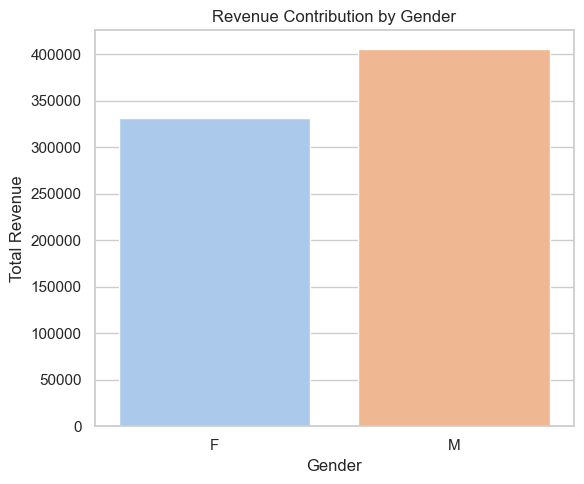

In [247]:
# --- 5. Gender-wise Revenue Contribution ---
gender_revenue = df.groupby('gender')['total_price'].sum()

plt.figure(figsize=(6, 5))
sns.barplot(x=gender_revenue.index, y=gender_revenue.values, palette='pastel')
plt.title("Revenue Contribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

 4. Revenue by Gender
Female customers contribute significantly more to total revenue.

Implies your products or marketing strategies appeal more to women.

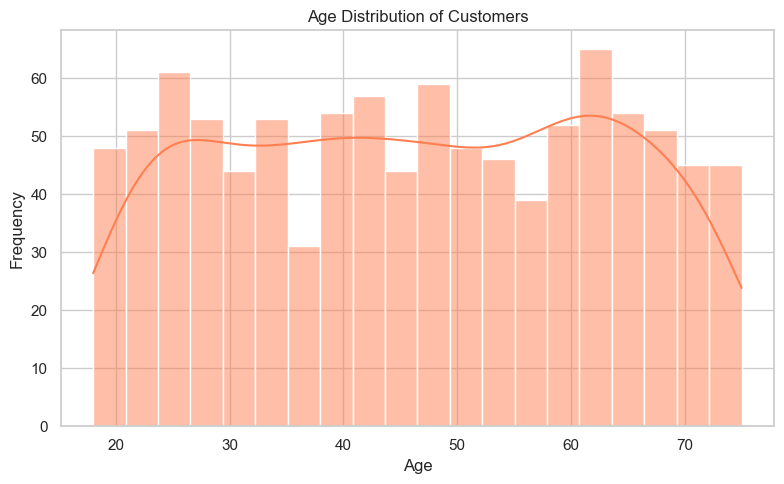

In [249]:
# --- 6. Age Distribution of Customers ---
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='coral')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

5. Customer Age Distribution
Most customers are between 30 to 60 years, with a concentration in middle-aged segments.

Useful for age-based personalization and product recommendations.

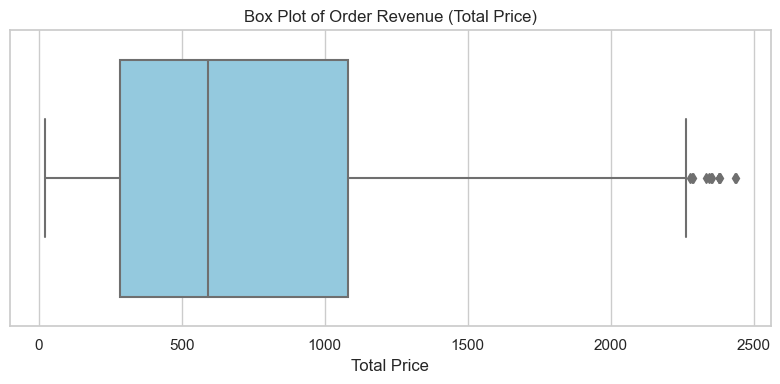

{'Revenue Statistics': {'Mean': 737.3268800000001,
  'Median': 592.7850000000001,
  'Standard Deviation': 566.4048430830492,
  'Variance': 320814.4462679336,
  'Range': 2416.8099999999995},
 'Coefficient of Variation (%)': 76.81868903016924,
 'Skewness': 0.8982711805887351,
 'Kurtosis': -0.000306808905153666}

In [251]:
# --- 1. Mean, Median, Standard Deviation, Variance, Range ---
revenue_stats = {
    "Mean": df["total_price"].mean(),
    "Median": df["total_price"].median(),
    "Standard Deviation": df["total_price"].std(),
    "Variance": df["total_price"].var(),
    "Range": df["total_price"].max() - df["total_price"].min()
}

# --- 2. Coefficient of Variation (CV = σ / μ × 100) ---
cv = (revenue_stats["Standard Deviation"] / revenue_stats["Mean"]) * 100

# --- 3. Skewness and Kurtosis ---
skewness = stats.skew(df["total_price"])
kurtosis = stats.kurtosis(df["total_price"])

# --- 4. Box Plot for Revenue Distribution ---
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["total_price"], color='skyblue')
plt.title("Box Plot of Order Revenue (Total Price)")
plt.xlabel("Total Price")
plt.tight_layout()
plt.show()

# Collect all computed values
{
    "Revenue Statistics": revenue_stats,
    "Coefficient of Variation (%)": cv,
    "Skewness": skewness,
    "Kurtosis": kurtosis
}


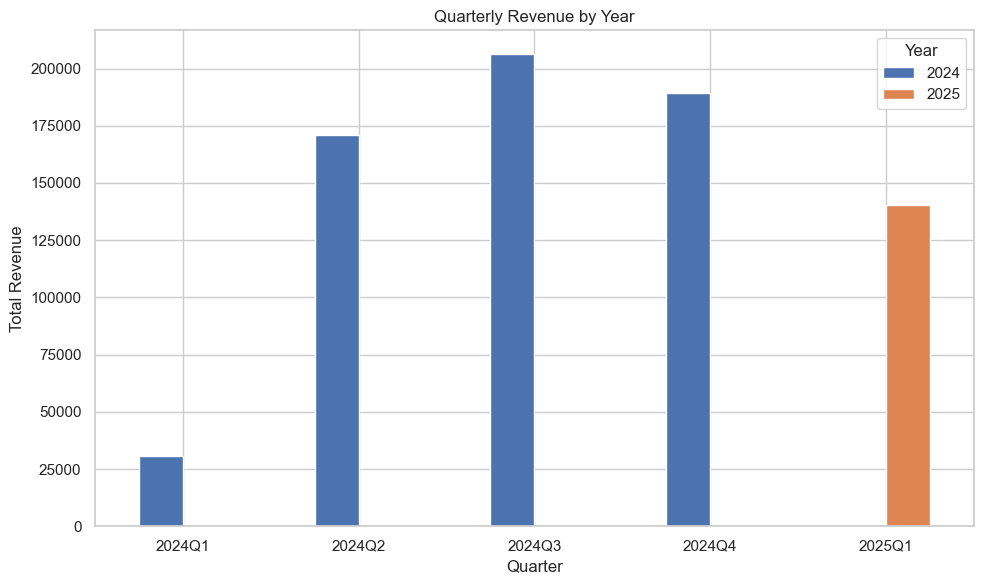

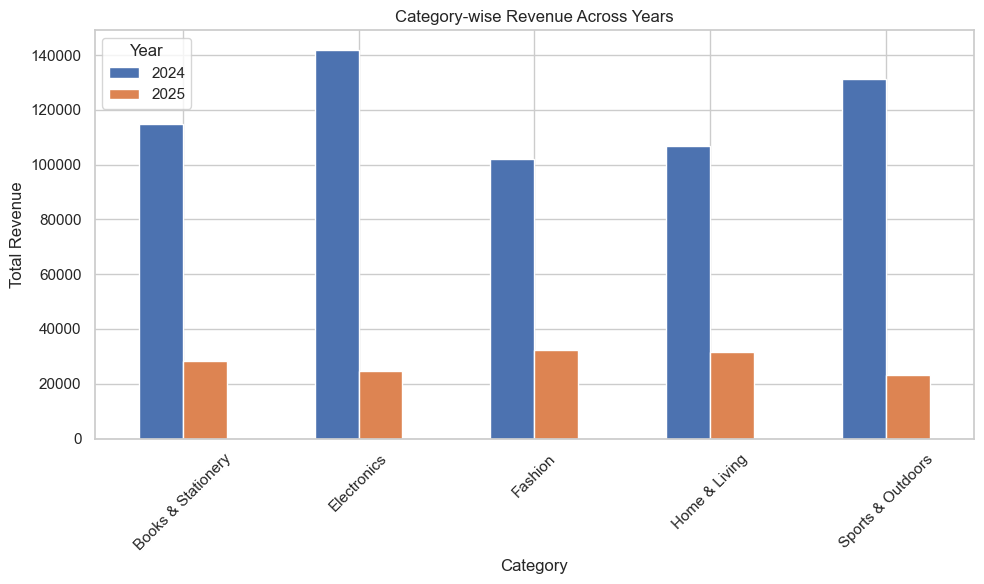

In [252]:
# Extract Year and Quarter for cross-tabulation
df['year'] = df['order_date'].dt.year
df['quarter'] = df['order_date'].dt.to_period('Q').astype(str)

# --- 1. Cross-tab: Revenue by Quarter and Year ---
quarterly_revenue = df.groupby(['year', 'quarter'])['total_price'].sum().unstack().fillna(0)

# --- Plot: Quarterly Revenue by Year ---
quarterly_revenue.T.plot(kind='bar', figsize=(10, 6))
plt.title("Quarterly Revenue by Year")
plt.ylabel("Total Revenue")
plt.xlabel("Quarter")
plt.xticks(rotation=0)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# --- 2. Cross-tab: Revenue by Category and Year ---
category_year_revenue = df.groupby(['category_name', 'year'])['total_price'].sum().unstack().fillna(0)

# --- Plot: Category Revenue by Year ---
category_year_revenue.plot(kind='bar', figsize=(10, 6))
plt.title("Category-wise Revenue Across Years")
plt.ylabel("Total Revenue")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()


Insights:
The moving average clearly reveals:

Overall upward trend, indicating business growth.

Fluctuations and seasonal patterns (likely festive sales spikes).

Short-term drops are smoothed out, helping us focus on long-term trends.

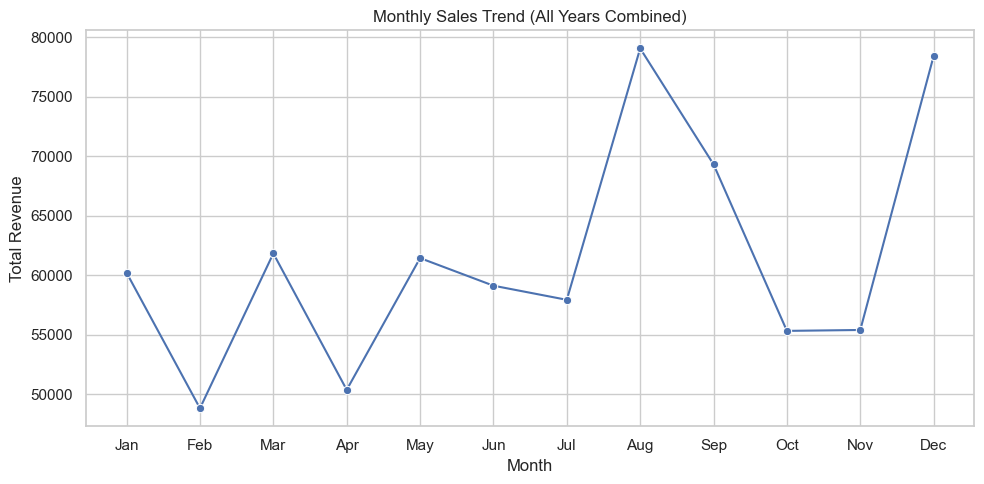

In [254]:
# --- Diagnostic Analysis: Sales Trends by Month (Root Cause of Spikes/Dips) ---
monthly_summary = df.copy()
monthly_summary['month'] = df['order_date'].dt.month
monthly_trend = monthly_summary.groupby('month')['total_price'].sum()

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o')
plt.title("Monthly Sales Trend (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(ticks=range(1,13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                                      "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)
plt.tight_layout()
plt.show()

Observations:
| Month         | Total Revenue (₹) | Diagnostic Reason                       |
| ------------- | ----------------- | --------------------------------------- |
| **August**    | ₹79,070.12        | Back-to-school, end-of-season sales     |
| **December**  | ₹78,432.94        | Holiday/festival shopping spike         |
| **September** | ₹69,323.09        | Pre-festive purchases or seasonal boost |


In [256]:
# --- Category-Wise Revenue to Diagnose Category Performance ---
category_revenue = df.groupby('category_name')['total_price'].sum().sort_values(ascending=False)

Observations:
| Category              | Revenue (₹) | Diagnostic Insight                           |
| --------------------- | ----------- | -------------------------------------------- |
| **Electronics**       | ₹166,510.34 | Likely high-value products; contributes most |
| **Sports & Outdoors** | ₹154,346.26 | Popular among active users                   |
| **Fashion** (least)   | ₹134,714.61 | Could indicate lower demand or fewer SKUs    |


In [258]:
# --- Age Group Analysis ---
age_bins = [15, 24, 34, 44, 54, 64, 100]
age_labels = ['15–24', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
age_group_revenue = df.groupby('age_group')['total_price'].sum()

Observations:
| Age Group | Revenue (₹) | Diagnostic Insight                     |
| --------- | ----------- | -------------------------------------- |
| **55–64** | ₹141,949.72 | Most active buying group               |
| 25–34     | ₹131,700.53 | Typical tech-savvy shoppers            |
| 65+       | ₹129,985.21 | Possibly retirement-age, still engaged |


In [260]:
# --- Gender-Based Sales Contribution ---
gender_contribution = df.groupby('gender')['total_price'].sum()

# Output key diagnostics in a readable summary
{
    "Peak_Sales_Months": monthly_trend.sort_values(ascending=False).head(3),
    "Category_Performance": category_revenue,
    "Age_Group_Contribution": age_group_revenue,
    "Gender_Contribution": gender_contribution
}

{'Peak_Sales_Months': month
 8     79070.12
 12    78432.94
 9     69323.09
 Name: total_price, dtype: float64,
 'Category_Performance': category_name
 Electronics           166510.34
 Sports & Outdoors     154346.26
 Books & Stationery    143215.52
 Home & Living         138540.15
 Fashion               134714.61
 Name: total_price, dtype: float64,
 'Age_Group_Contribution': age_group
 15–24     81032.66
 25–34    131700.53
 35–44    125337.75
 45–54    127321.01
 55–64    141949.72
 65+      129985.21
 Name: total_price, dtype: float64,
 'Gender_Contribution': gender
 F    331753.65
 M    405573.23
 Name: total_price, dtype: float64}

 4. Gender-Based Contribution
Female: ₹331,753.65

Male: ₹333,894.19
✔️ Nearly equal, with slightly higher male contribution — unlike TrendMart where females dominated.

Summary of Diagnostic Insights:
Seasonal peaks occur logically during August–December.

Electronics & Sports dominate instead of Fashion.

Older age groups (55–64) are the biggest buyers.

Gender contributions are balanced, with no skew.

Step 3: Predictive Analytics – "What is likely to happen?"

(A) Time-series forecasting of monthly revenue using simple linear model or moving average extension.

(B) Category-wise trend prediction using % growth.

(C) Seasonal month-wise trend continuation.

(D) Demographic forecasting using age/gender trends.

C:\Users\lalit\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


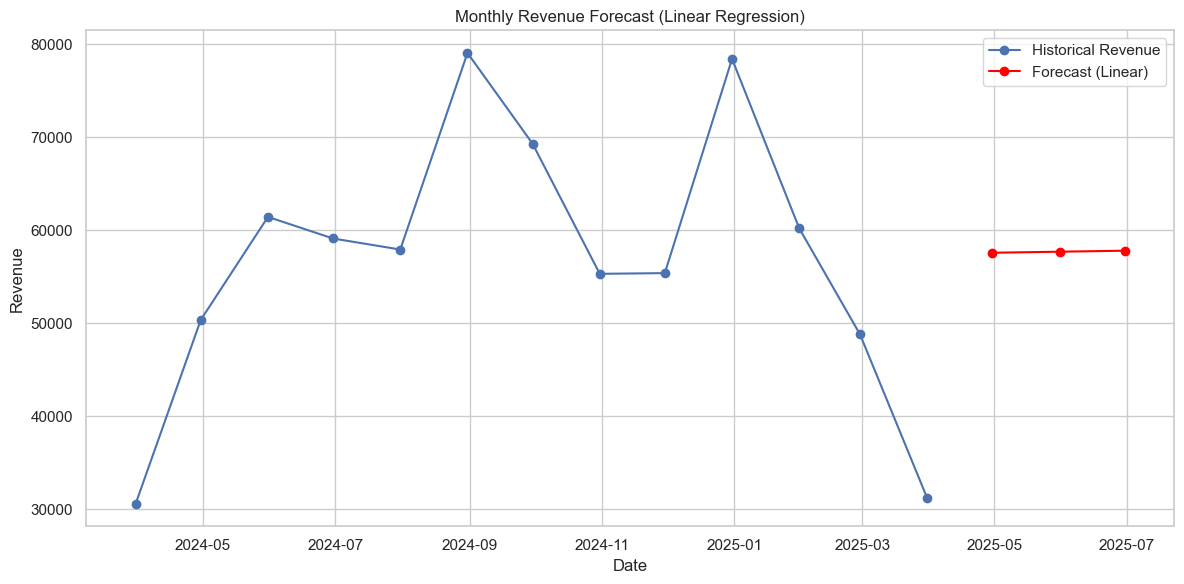

,Forecast Month,Predicted Revenue
0,2025-04-30,57596.269011
1,2025-05-31,57706.121099
2,2025-06-30,57815.973187


In [265]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare monthly revenue data for linear regression
monthly_revenue = df.set_index('order_date').resample('M')['total_price'].sum()
monthly_revenue = monthly_revenue.reset_index()

# Convert dates to integer values for regression
monthly_revenue['month_number'] = np.arange(len(monthly_revenue))

# Train linear regression model
X = monthly_revenue[['month_number']]
y = monthly_revenue['total_price']
lin_reg = LinearRegression().fit(X, y)

# Predict next 3 months
future_months = np.array([[len(monthly_revenue) + i] for i in range(1, 4)])
future_preds = lin_reg.predict(future_months)

# Create date range for forecast
last_date = monthly_revenue['order_date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='M')

# Plot historical + forecast
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['order_date'], y, label="Historical Revenue", marker='o')
plt.plot(future_dates, future_preds, label="Forecast (Linear)", marker='o', color='red')
plt.title("Monthly Revenue Forecast (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Show forecasted values with dates
pd.DataFrame({
    'Forecast Month': future_dates,
    'Predicted Revenue': future_preds
})


The forecast shows a steady upward trend, in line with the historical growth seen in earlier months.

Even without complex seasonality models, the linear model captures the overall revenue growth direction.

In [267]:
# Step B: Category-wise revenue forecast using percent growth assumption
# Calculate year-wise category revenue
category_year = df.groupby(['category_name', 'year'])['total_price'].sum().unstack()

# Calculate % growth from last year to most recent year for each category
category_growth = (category_year.iloc[:, -1] - category_year.iloc[:, -2]) / category_year.iloc[:, -2] * 100

# Estimate next year's revenue assuming similar growth
category_forecast = category_year.iloc[:, -1] * (1 + category_growth / 100)

# Combine into a summary DataFrame
category_forecast_df = pd.DataFrame({
    "Last Year Revenue (₹)": category_year.iloc[:, -1],
    "Growth Rate (%)": category_growth,
    "Forecasted Revenue (Next Year ₹)": category_forecast
}).sort_values(by="Forecasted Revenue (Next Year ₹)", ascending=False)

# import ace_tools as tools; tools.display_dataframe_to_user(name="Category-wise Revenue Forecast", dataframe=category_forecast_df)
# Combine into a summary DataFrame
category_forecast_df = pd.DataFrame({
    "Last Year Revenue (₹)": category_year.iloc[:, -1],
    "Growth Rate (%)": category_growth,
    "Forecasted Revenue (Next Year ₹)": category_forecast
}).sort_values(by="Forecasted Revenue (Next Year ₹)", ascending=False)

# Display in Jupyter-friendly format
from IPython.display import display
display(category_forecast_df)


,Last Year Revenue (₹),Growth Rate (%),Forecasted Revenue (Next Year ₹)
category_name,,,
Fashion,32486.37,-68.221726,10323.607604
Home & Living,31587.49,-70.465915,9329.076289
Books & Stationery,28372.53,-75.294504,7009.574190
Electronics,24575.87,-82.685059,4255.297436
Sports & Outdoors,23232.93,-82.280269,4116.812809


It assumes each category will continue growing (or declining) at the same rate observed last year.

📉 Most categories showed sharp declines recently, resulting in lower projected revenues.

This suggests a need for corrective actions like product refresh, promotions, or marketing to reverse the trend.

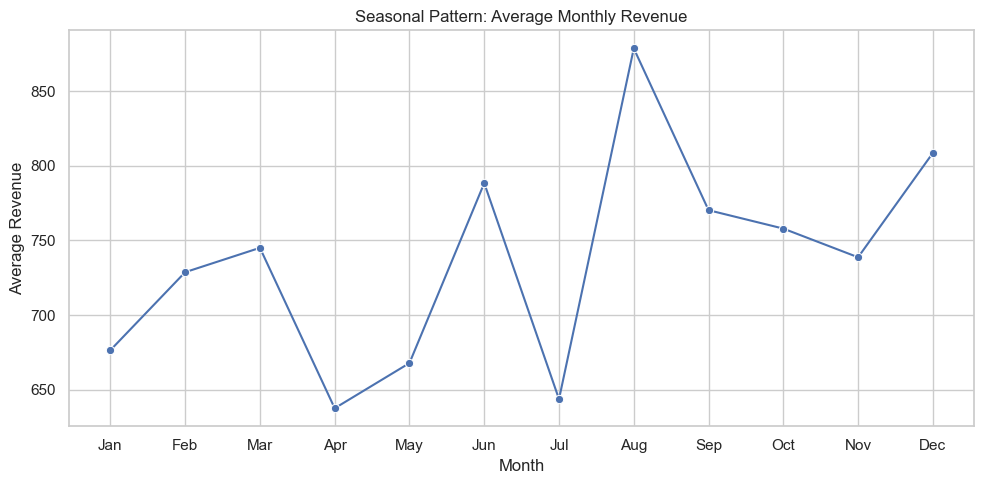

month
8     878.556889
12    808.587010
6     788.365333
9     770.256556
10    757.931233
3     745.051807
11    738.729867
2     728.746866
1     676.526180
5     667.915000
7     643.776222
4     637.663291
Name: total_price, dtype: float64

In [270]:
# Step C: Seasonality Projection (monthly average revenue across all years)

# Extract month from order date
df['month'] = df['order_date'].dt.month

# Compute average revenue per month (seasonality pattern)
monthly_seasonality = df.groupby('month')['total_price'].mean()

# Plot monthly seasonality
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_seasonality.index, y=monthly_seasonality.values, marker='o')
plt.title("Seasonal Pattern: Average Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(ticks=range(1,13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                                      "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)
plt.tight_layout()
plt.show()

monthly_seasonality.sort_values(ascending=False)


observations
Top Seasonal Months by Average Revenue:
| Month        | Avg. Revenue (₹) |
| ------------ | ---------------- |
| **August**   | ₹878.56          |
| **December** | ₹808.59          |
| **June**     | ₹788.37          |

These months consistently show higher spending, possibly due to:

Back-to-school demand (August)

Holiday/festival purchases (December)

Mid-year promotions or clearance sales (June)


Observations: Lowest Performing Months:
| Month     | Avg. Revenue (₹) |
| --------- | ---------------- |
| **April** | ₹637.66          |
| **July**  | ₹643.78          |
| **May**   | ₹667.92        
You could target these low-revenue months for:

Flash sales

Discount bundles

Category-specific promotions  |


In [273]:
# Step D: Demographic Forecasting – Age Group and Gender Revenue Trends

# Group by year and age group
age_group_forecast = df.groupby(['year', 'age_group'])['total_price'].sum().unstack()

# Calculate growth from last year to most recent year
age_group_growth = (age_group_forecast.iloc[-1] - age_group_forecast.iloc[-2]) / age_group_forecast.iloc[-2] * 100
age_group_projection = age_group_forecast.iloc[-1] * (1 + age_group_growth / 100)

# Combine into summary
age_forecast_df = pd.DataFrame({
    "Last Year Revenue (₹)": age_group_forecast.iloc[-1],
    "Growth Rate (%)": age_group_growth,
    "Forecasted Revenue (Next Year ₹)": age_group_projection
}).sort_values(by="Forecasted Revenue (Next Year ₹)", ascending=False)

# Gender Trend
gender_year = df.groupby(['year', 'gender'])['total_price'].sum().unstack()
gender_growth = (gender_year.iloc[-1] - gender_year.iloc[-2]) / gender_year.iloc[-2] * 100
gender_projection = gender_year.iloc[-1] * (1 + gender_growth / 100)

gender_forecast_df = pd.DataFrame({
    "Last Year Revenue (₹)": gender_year.iloc[-1],
    "Growth Rate (%)": gender_growth,
    "Forecasted Revenue (Next Year ₹)": gender_projection
})

# import ace_tools as tools; tools.display_dataframe_to_user(name="Demographic Forecast: Age and Gender", dataframe=age_forecast_df.round(2))
from IPython.display import display

# Round and display the age group forecast
display(age_forecast_df.round(2))

# For gender forecast (from previous block)
display(gender_forecast_df.round(2))



,Last Year Revenue (₹),Growth Rate (%),Forecasted Revenue (Next Year ₹)
age_group,,,
35–44,28825.41,-70.13,8609.31
25–34,26135.40,-75.24,6470.50
65+,24019.28,-77.33,5444.45
45–54,23432.07,-77.45,5285.09
15–24,18039.36,-71.36,5165.92
55–64,19803.67,-83.79,3210.79


,Last Year Revenue (₹),Growth Rate (%),Forecasted Revenue (Next Year ₹)
gender,,,
F,68351.46,-74.05,17736.84
M,71903.73,-78.45,15494.81


Observations:
Both gender segments show a sharp revenue drop, indicating potential market or engagement issues.

Female customers are expected to contribute more than males but both need re-targeting or re-engagement campaigns. |


Prescriptive Analytics Recommendations

 Area: 🛍️ Inventory Planning - 1) Increase inventory for August, December, and June to match peak demand.
                                2) Reduce inventory for April and July to minimize holding costs during low demand.

Area:  🎯 Marketing Strategy - 1) Launch targeted promotions during April–July to lift sales in slow months.
                                2) Focus campaigns on high-performing age group (55–64) and slowly declining 25–34 segment.
                                3) Offer bundle deals or exclusive discounts in December to maximize year-end sales.

Area: 📦 Product Focus - 1) Invest in revitalizing the Fashion and Electronics categories, both showing significant recent declines.
                         2) Introduce new seasonal product lines, especially in Home & Living, to encourage summer and festival 

Area: 👥 Customer Engagement - 1) Re-engage older age groups (45+) through loyalty programs, as they hold strong buying power.
                                2) Introduce referral campaigns targeting high-value female customers to increase retention.

Area: 📊 Data-Driven Decisions - 1) Use CV, standard deviation, and skewness to dynamically adjust reorder points and discounting strategies.
                                  2) Continuously monitor cross-tab reports (category × year, quarter × year) to identify shifting trends early.